# **Pairwise Random Forest Biomarker Discovery**


Dataset = GSE183276_HVG3000_by_variance.h5ad
Features = Top 3000 HVG genes
Model = Random Forest
Goal = Pairwise disease biomarkers
```

---

# What this will do

৩টা separate ML task:

| Task             | Meaning                     |
| ---------------- | --------------------------- |
| AKI vs reference | acute injury biomarkers     |
| CKD vs reference | chronic fibrosis biomarkers |
| CKD vs AKI       | progression biomarkers      |

---

# Important Difference

আগে:

```text
One multiclass RF
```

এখন:

```text
Separate binary RF for each comparison
```

এটা scientifically অনেক stronger।


---

# Scientifically What This Finds

## AKI vs Reference

```text
Acute injury biomarkers
```

Likely:

* HAVCR1
* LCN2

---

## CKD vs Reference

```text
Fibrosis biomarkers
```

Likely:

* COL1A1
* FN1

---

## CKD vs AKI

```text
Progression biomarkers
```

Meaning:

```text
Genes changing from acute injury
toward chronic fibrosis
```

Very valuable scientifically.

---

# Output Files

Example:

```text
AKI_vs_reference_RF_biomarkers.csv
CKD_vs_reference_RF_biomarkers.csv
CKD_vs_AKI_RF_biomarkers.csv
```

Each contains:

| Column          | Meaning                  |
| --------------- | ------------------------ |
| gene            | biomarker gene           |
| importance      | RF importance            |
| diff_expression | mean difference          |
| direction       | which class upregulated  |
| combined_score  | final RF biomarker score |



===== Dataset =====
AnnData object with n_obs × n_vars = 46720 × 3000
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module'
    var: 'n_cells', 

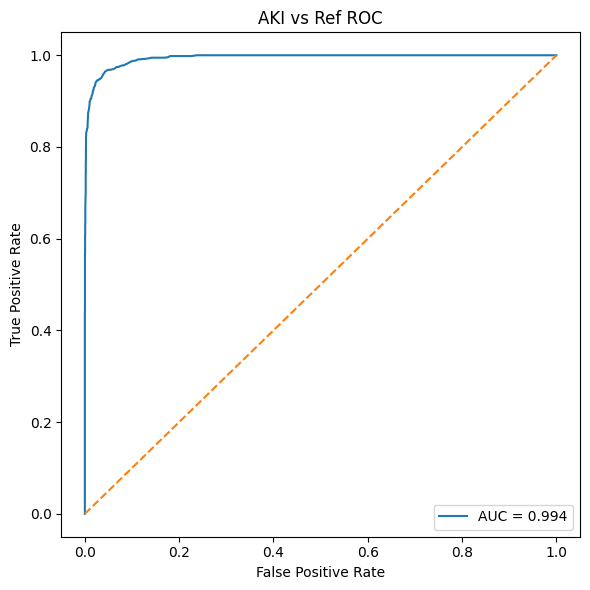


===== Top Biomarkers =====
          gene  direction  importance  diff_expression  combined_score
2956    MT-CYB  UP_in_Ref    0.014179        -0.372846        0.005287
2970    TMEM66  UP_in_Ref    0.003602        -0.795916        0.002867
2694   TSC22D3  UP_in_Ref    0.008132        -0.258528        0.002102
440      CEBPD  UP_in_AKI    0.009248         0.224547        0.002077
2944    MT-ND1  UP_in_Ref    0.012193        -0.141849        0.001730
2124     RPL28  UP_in_Ref    0.003606        -0.340160        0.001227
756       EGR1  UP_in_Ref    0.008809        -0.136088        0.001199
200    ATP5F1E  UP_in_AKI    0.003826         0.257192        0.000984
1233      KLF6  UP_in_Ref    0.003849        -0.240181        0.000924
2961    ATP5G3  UP_in_Ref    0.001965        -0.446883        0.000878
2419      SPP1  UP_in_Ref    0.010810        -0.077441        0.000837
2281   SERTAD1  UP_in_Ref    0.004980        -0.168007        0.000837
2631    TMSB10  UP_in_Ref    0.005762        -0.1

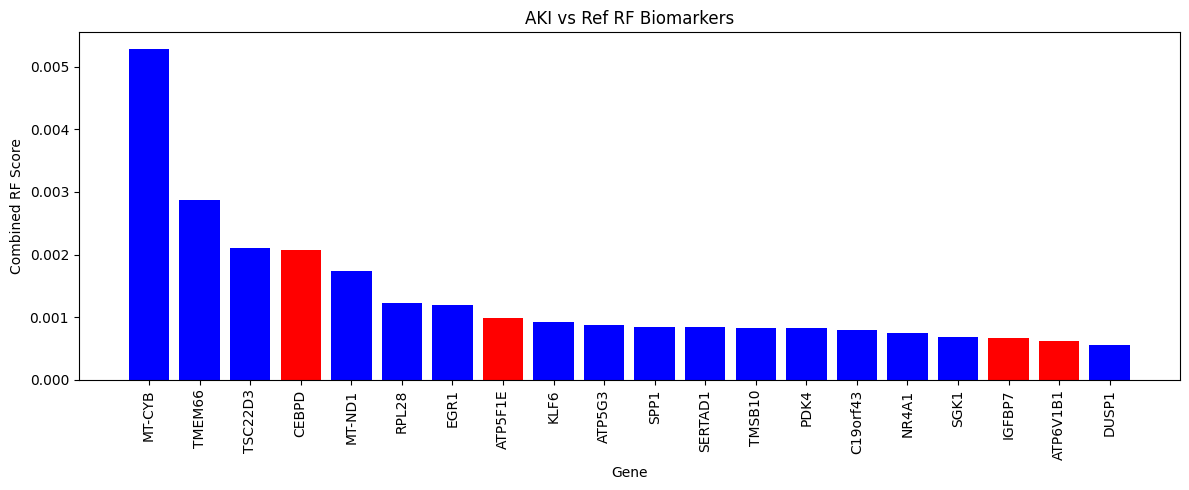


CKD vs Ref

Classes:
['CKD' 'Ref']

Train shape: (21367, 3000)
Test shape: (5342, 3000)

Training RF...
Training complete

===== Accuracy =====
0.9116435791838263

===== ROC-AUC =====
0.9899209310264305

===== Classification Report =====
              precision    recall  f1-score   support

         CKD       0.90      1.00      0.95      4207
         Ref       0.99      0.59      0.74      1135

    accuracy                           0.91      5342
   macro avg       0.94      0.79      0.84      5342
weighted avg       0.92      0.91      0.90      5342



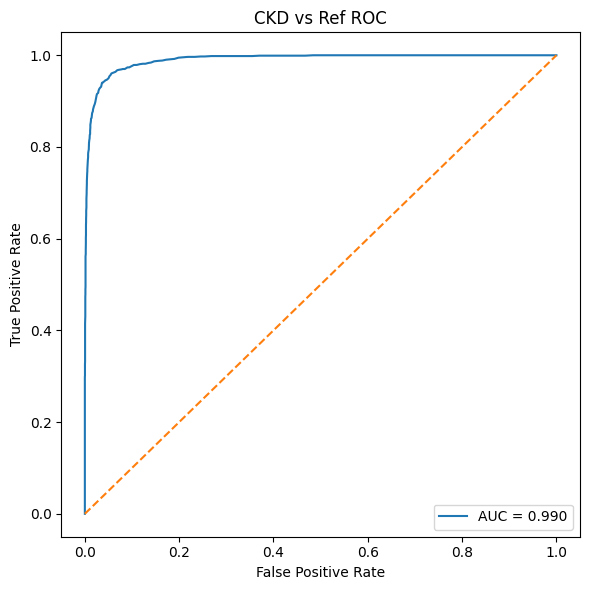


===== Top Biomarkers =====
          gene  direction  importance  diff_expression  combined_score
1649     NR4A1  UP_in_Ref    0.017685        -0.279935        0.004951
2110     RPL17  UP_in_CKD    0.010904         0.110878        0.001209
721      DUSP1  UP_in_CKD    0.009231         0.121384        0.001121
1628      NME2  UP_in_CKD    0.008170         0.136243        0.001113
2205   S100A11  UP_in_Ref    0.004759        -0.214724        0.001022
2028     RASD1  UP_in_Ref    0.003332        -0.270783        0.000902
923    GADD45A  UP_in_Ref    0.004831        -0.183211        0.000885
1751      PDK4  UP_in_Ref    0.013010        -0.064000        0.000833
1372      MCL1  UP_in_Ref    0.003076        -0.264026        0.000812
2292      SGK1  UP_in_CKD    0.009054         0.082241        0.000745
1208      JUND  UP_in_CKD    0.005213         0.138952        0.000724
756       EGR1  UP_in_Ref    0.004848        -0.147155        0.000713
2957   MICOS10  UP_in_Ref    0.006592        -0.1

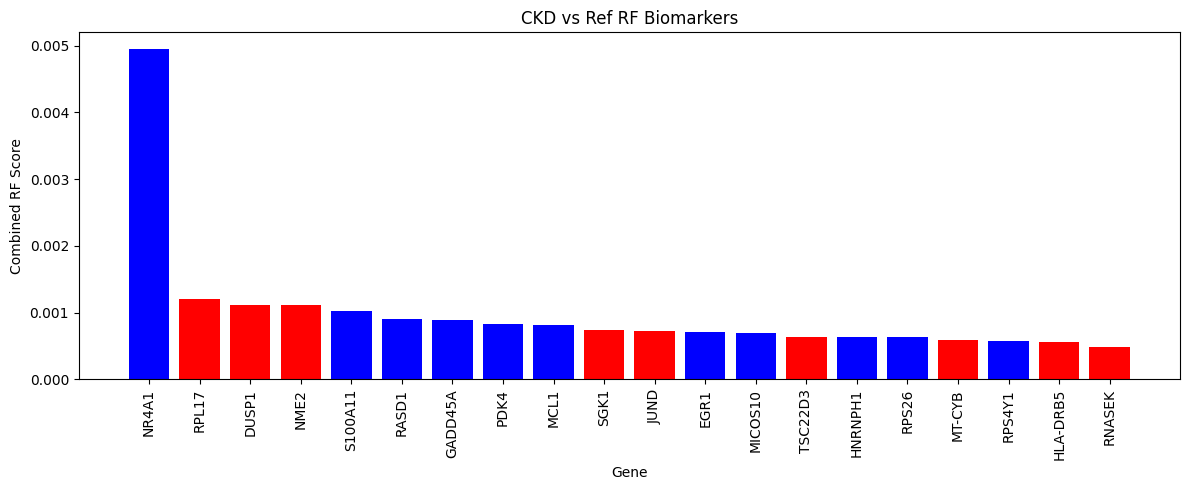


CKD vs AKI

Classes:
['AKI' 'CKD']

Train shape: (32837, 3000)
Test shape: (8210, 3000)

Training RF...
Training complete

===== Accuracy =====
0.8869671132764921

===== ROC-AUC =====
0.9590904108307063

===== Classification Report =====
              precision    recall  f1-score   support

         AKI       0.87      0.90      0.89      4002
         CKD       0.90      0.88      0.89      4208

    accuracy                           0.89      8210
   macro avg       0.89      0.89      0.89      8210
weighted avg       0.89      0.89      0.89      8210



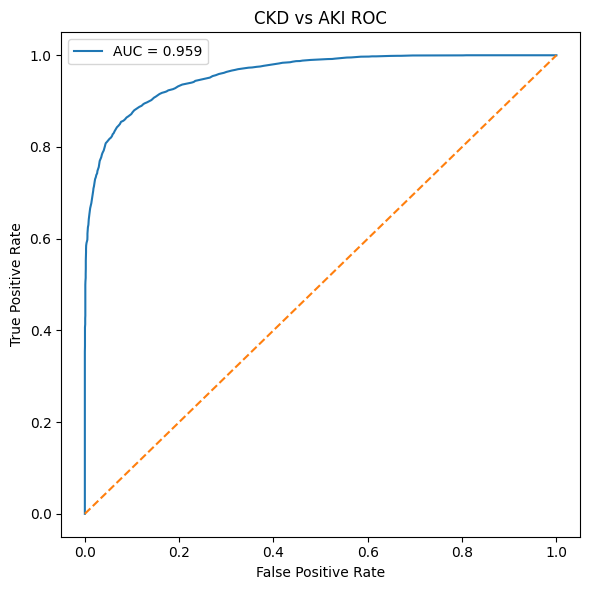


===== Top Biomarkers =====
          gene  direction  importance  diff_expression  combined_score
2181    RPS4Y1  UP_in_CKD    0.026653         0.092911        0.002476
2949   MT-ATP6  UP_in_CKD    0.002569         0.525134        0.001349
2944    MT-ND1  UP_in_AKI    0.006680        -0.142305        0.000951
2013     RACK1  UP_in_CKD    0.005284         0.153243        0.000810
2958    SNHG29  UP_in_CKD    0.009623         0.077848        0.000749
2990  UQCR11.1  UP_in_AKI    0.003508        -0.197502        0.000693
42       ADIRF  UP_in_CKD    0.005514         0.117503        0.000648
191     ATP1B1  UP_in_CKD    0.001514         0.404837        0.000613
2957   MICOS10  UP_in_CKD    0.005811         0.104145        0.000605
2079    RNASEK  UP_in_CKD    0.008782         0.068657        0.000603
1628      NME2  UP_in_CKD    0.007992         0.067667        0.000541
2110     RPL17  UP_in_CKD    0.008926         0.057764        0.000516
2129     RPL32  UP_in_CKD    0.000763         0.6

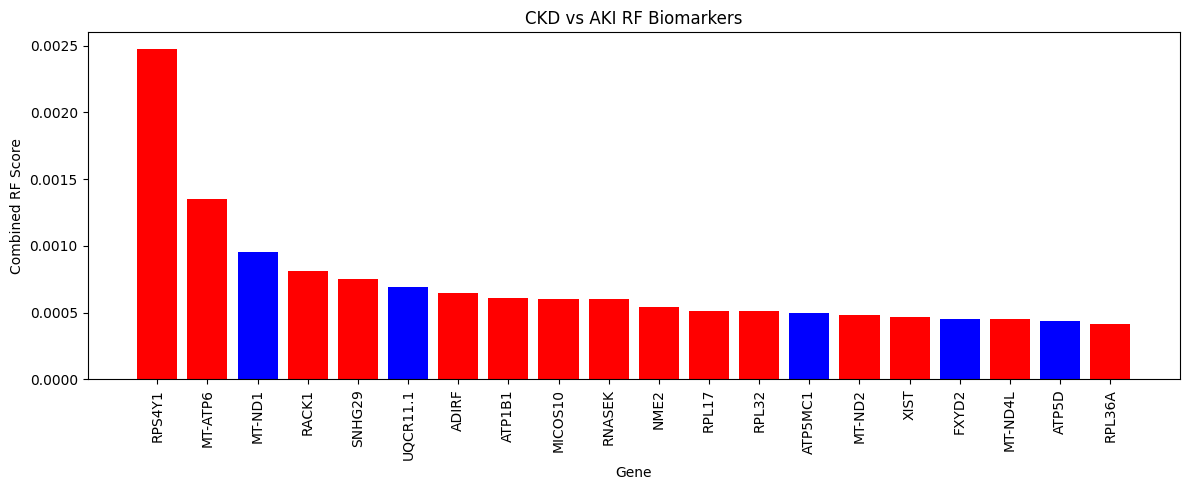


Done!


In [4]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# =========================================
# Load HVG dataset
# =========================================

adata = sc.read_h5ad(
    RESULTS_DIR / "GSE183276_HVG3000_by_variance.h5ad"
)

label_col = "condition.l1"

adata = adata[
    ~adata.obs[label_col].isna()
].copy()

print("\n===== Dataset =====")
print(adata)

print("\n===== Classes =====")
print(
    adata.obs[label_col].value_counts()
)

# =========================================
# Pairwise comparisons
# =========================================

comparisons = [

    ("AKI", "Ref"),
    ("CKD", "Ref"),
    ("CKD", "AKI")

]

# =========================================
# Expression matrix
# =========================================

X_all = adata.X

if sparse.issparse(X_all):
    X_all = X_all.toarray()

genes = adata.var_names

# =========================================
# Run pairwise RF
# =========================================

for positive_class, negative_class in comparisons:

    print("\n====================================")
    print(f"{positive_class} vs {negative_class}")
    print("====================================")

    # =====================================
    # Select cells
    # =====================================

    subset = adata[
        adata.obs[label_col].isin(
            [positive_class, negative_class]
        )
    ].copy()

    X = subset.X

    if sparse.issparse(X):
        X = X.toarray()

    y = subset.obs[label_col].astype(str)

    # =====================================
    # Encode labels
    # =====================================

    le = LabelEncoder()

    y_encoded = le.fit_transform(y)

    print("\nClasses:")
    print(le.classes_)

    # =====================================
    # Train/Test split
    # =====================================

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_encoded
    )

    print("\nTrain shape:", X_train.shape)
    print("Test shape:", X_test.shape)

    # =====================================
    # Random Forest
    # =====================================

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

    print("\nTraining RF...")

    rf.fit(X_train, y_train)

    print("Training complete")

    # =====================================
    # Prediction
    # =====================================

    y_pred = rf.predict(X_test)

    y_prob = rf.predict_proba(X_test)[:,1]

    # =====================================
    # Metrics
    # =====================================

    acc = accuracy_score(
        y_test,
        y_pred
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    print("\n===== Accuracy =====")
    print(acc)

    print("\n===== ROC-AUC =====")
    print(auc_score)

    report = classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )

    print("\n===== Classification Report =====")
    print(report)

    # save report
    with open(
        RESULTS_DIR /
        f"{positive_class}_vs_{negative_class}_RF_report.txt",
        "w"
    ) as f:

        f.write(report)

    # =====================================
    # Confusion Matrix
    # =====================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    cm_df = pd.DataFrame(
        cm,
        index=le.classes_,
        columns=le.classes_
    )

    cm_df.to_csv(
        RESULTS_DIR /
        f"{positive_class}_vs_{negative_class}_RF_confusion_matrix.csv"
    )

    # =====================================
    # ROC Curve
    # =====================================

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    plt.figure(figsize=(6,6))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {auc_score:.3f}"
    )

    plt.plot([0,1],[0,1],"--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(
        f"{positive_class} vs {negative_class} ROC"
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        RESULTS_DIR /
        f"{positive_class}_vs_{negative_class}_ROC.png",
        dpi=300
    )

    plt.show()

    # =====================================
    # Feature importance
    # =====================================

    importance_df = pd.DataFrame({

        "gene": genes,
        "importance": rf.feature_importances_

    })

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False
    )

    # direction
    mean_pos = X[y == positive_class].mean(axis=0)
    mean_neg = X[y == negative_class].mean(axis=0)

    importance_df["mean_positive"] = mean_pos
    importance_df["mean_negative"] = mean_neg

    importance_df["diff_expression"] = (
        mean_pos - mean_neg
    )

    importance_df["direction"] = np.where(
        importance_df["diff_expression"] > 0,
        f"UP_in_{positive_class}",
        f"UP_in_{negative_class}"
    )

    # combined score
    importance_df["combined_score"] = (
        importance_df["importance"]
        *
        np.abs(
            importance_df["diff_expression"]
        )
    )

    importance_df = importance_df.sort_values(
        "combined_score",
        ascending=False
    )

    # =====================================
    # Save biomarkers
    # =====================================

    importance_df.to_csv(
        RESULTS_DIR /
        f"{positive_class}_vs_{negative_class}_RF_biomarkers.csv",
        index=False
    )

    print("\n===== Top Biomarkers =====")
    print(
        importance_df.head(20)[
            [
                "gene",
                "direction",
                "importance",
                "diff_expression",
                "combined_score"
            ]
        ]
    )

    # =====================================
    # Plot top genes
    # =====================================

    top20 = importance_df.head(20)

    colors = [
        "red" if x > 0 else "blue"
        for x in top20["diff_expression"]
    ]

    plt.figure(figsize=(12,5))

    plt.bar(
        top20["gene"],
        top20["combined_score"],
        color=colors
    )

    plt.xticks(rotation=90)

    plt.xlabel("Gene")
    plt.ylabel("Combined RF Score")

    plt.title(
        f"{positive_class} vs {negative_class} RF Biomarkers"
    )

    plt.tight_layout()

    plt.savefig(
        RESULTS_DIR /
        f"{positive_class}_vs_{negative_class}_RF_top20.png",
        dpi=300
    )

    plt.show()

print("\nDone!")